In [1]:
import psycopg2 as pg
from sqlalchemy import create_engine

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Database connection parameters
DB_USER = 'postgres'
DB_PASSWORD = 'gogilbert9812806'
DB_NAME = 'psp_db'
DB_HOST = 'localhost'
DB_PORT = '5432'

# Connection string
conn_str = f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

# Connect to Database
engine = create_engine(conn_str)

In [3]:
# Querying the Database to retrieve relevant data
query = """
    SELECT
        b.plantation,
        p.block,
        b."year planted",
        b."block area (ha)",
        p.plot,
        pmh."Default plot size",
        pmh."Plot type",
        d.area_type,
        d."monitoring year",
        d.tree_id,
        d."Tree SPECIES",
        d.height_m,
        d.dbh_cm,
        d.remarks
    FROM block_register b
    JOIN plot_block_relation p
        ON b.plantation = p.plantation
        AND b.block = p.block
    JOIN plot_monitoring_history pmh
        ON pmh.plantation = p.plantation
        AND pmh.plot = p.plot
    JOIN treedata d
        ON b.plantation = d.plantation
        AND d.plot = p.plot
        AND d.area_type = 'Teak';
"""

# Convert the retrieved data from the database to pandas dataframe
df = pd.read_sql_query(query, engine)


# View the first 5 rows to the dataset
df.head()

,plantation,block,year planted,block area (ha),plot,Default plot size,Plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks
0,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars
1,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars
2,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars
3,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars
4,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars


In [4]:
# Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8577780 entries, 0 to 8577779
Data columns (total 14 columns):
 #   Column             Dtype  
---  ------             -----  
 0   plantation         object 
 1   block              object 
 2   year planted       int64  
 3   block area (ha)    float64
 4   plot               object 
 5   Default plot size  float64
 6   Plot type          object 
 7   area_type          object 
 8   monitoring year    float64
 9   tree_id            float64
 10  Tree SPECIES       object 
 11  height_m           float64
 12  dbh_cm             float64
 13  remarks            object 
dtypes: float64(6), int64(1), object(7)
memory usage: 916.2+ MB


In [5]:
# The shape of the dataset
df.shape

(8577780, 14)

In [6]:
# Check for null values in the dataset
df.isna().sum()

plantation                 0
block                      0
year planted               0
block area (ha)            0
plot                       0
Default plot size          0
Plot type                  0
area_type                  0
monitoring year            0
tree_id                   72
Tree SPECIES            1544
height_m                4788
dbh_cm                 11404
remarks              5785624
dtype: int64

In [9]:
# Remove the null values in height and diameter
df.dropna(subset=['height_m', 'dbh_cm'], inplace=True)

In [10]:
# Verify if all null values in the height and diameter are removed
df.isna().sum()

plantation                 0
block                      0
year planted               0
block area (ha)            0
plot                       0
Default plot size          0
Plot type                  0
area_type                  0
monitoring year            0
tree_id                    0
Tree SPECIES            1468
height_m                   0
dbh_cm                     0
remarks              5778388
dtype: int64

In [11]:
# Review this remarks to check if there are values that need to be removed
df['remarks'].unique()

array(['Fire scars', None, 'Beetle infestation', 'Top broken', 'Coppice',
       'Broken top', 'Forked', 'Dead tree', 'Forked at 30 cm',
       'Fork at 2m', 'Nearly dead', '2 stems', 'Beside a termite mould',
       'leaves eaten by grasshoppers', 'Wildling',
       'Outside planting line - Wildling', 'marked',
       'bark damaged by termites', 'Dead tree - marked',
       'Has leaves to about 6m', 'dead tree, but resprouting',
       'Sapling - Wildling', 'Black ant attack from base to top',
       'dead tree, but coppicing', 'Old teak stand', 'Double stem',
       '3 stems', 'The tree is highly branched at this height sideways',
       'Dying', 'ceber', 'Main tree dead', 'Top dead', '', 'Beaten-up',
       'Taken with metre tape', 'DBH taken with metre tape',
       'Forked at DBH, taken above', 'No leaves, but alive',
       'Taken with metre tape.', 'Diseased', 'top slashed',
       'Teak dieback', 'Dbh taken with metre tape', 'Top dead - Wildling',
       'Circumference', 'Beate

In [16]:
# List of all unwanted remarks
unwanted = r"(Wildling|Coppice|Broken top|diseased|Top broken|coppice|wildling|fork|Beetle|Old|dieback|die back|Dying|Diseased|Broken|Abnormal|crooked|marked|dead|Dead,Top broken|Top broken,Half dead|dead,marked|Marked|Abnomal tree)"

# Remove the unwanted values
mask = df['remarks'].str.contains(unwanted, case=False, na=False)
df = df[~mask]

C:\Users\GILBERT FG\AppData\Local\Temp\ipykernel_13280\1576740686.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df['remarks'].str.contains(unwanted, case=False, na=False)


In [17]:
# Verify if the unwanted are removed
df['remarks'].unique()

array(['Fire scars', None, '2 stems', 'Beside a termite mould',
       'leaves eaten by grasshoppers', 'bark damaged by termites',
       'Has leaves to about 6m', 'Black ant attack from base to top',
       'Double stem', '3 stems',
       'The tree is highly branched at this height sideways', 'ceber', '',
       'Beaten-up', 'Taken with metre tape', 'DBH taken with metre tape',
       'No leaves, but alive', 'Taken with metre tape.', 'top slashed',
       'Dbh taken with metre tape', 'Circumference',
       'Beaten-up. Top slashed', 'Sunto', 'sunto', '2012 teak',
       '2012 teak, top slashed', '2012 burnt teak', 'already planted',
       'Diameter taken with diameter tape', 'Tape',
       'Hole in it. Diameter taken with diameter tape',
       'Measured with diameter tape. Diameter taken with diameter tape',
       'Diameter < 0. Diameter taken with diameter tape',
       'diseasesed - Diameter taken with diameter tape',
       'No DHB entered. Diameter taken with diameter tape. DB

In [18]:
df.shape

(8082608, 14)

In [19]:
# Check for tree species that are not needed. Only teak trees are needed.
df['Tree SPECIES'].unique()

array(['Teak', 'York', 'onyono', 'Mahogany', None, 'Albizia',
       'Awiemfosamina', 'Kyenkyen', 'Sofo', 'Onyina', 'Cassia', 'Wawa',
       'Unknown indigenous', 'Asanfena', 'Hontan', 'Akuakuo-Ninsuo',
       'Okoro', 'Nyankyerene', 'Watapuo', 'Akonkodie', 'Mango',
       'kwakuanisuo', 'Hyedua', 'Nyamedua', 'kotrenfro', 'Ofram',
       'Konkroma', 'Cedrela', 'Khaya ivorensis', 'Albizia adianthifolia',
       'Kane', 'Wama', 'Wonton', 'Odum', 'Trilepisium madagascariense',
       'Tetrapleura tetraptera', 'Kusia', 'Okure', 'Foto', 'Womba',
       'Alstonia boonei', 'Anacardium occidentale', 'Afzelia', 'Otie',
       'coconisuol', 'prekese', 'Kotreamfo', 'Acacia', 'Akye', 'Nofotene',
       'Acasia', 'Kigelia africana', 'Prekese', 'Kookonisuo'],
      dtype=object)

In [20]:
# Remove all unwanted tree species except teak species
df = df[(df['Tree SPECIES'].str.lower() == 'teak')]

In [21]:
# Verify
df['Tree SPECIES'].unique()

array(['Teak'], dtype=object)

In [22]:
df.shape

(8038316, 14)

In [31]:
# Check for abnormal data using h/d ratio
df['hd_ratio'] = (df['height_m'] / df['dbh_cm']) * 100

df.head()


,plantation,block,year planted,block area (ha),plot,Default plot size,Plot type,area_type,monitoring year,tree_id,Tree SPECIES,height_m,dbh_cm,remarks,hd_ratio
0,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667
1,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667
2,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667
3,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667
4,Tain II,B39,2013,63.327094,1,729.0,Square,Teak,2018.0,71.0,Teak,7.25,12.0,Fire scars,60.416667


In [32]:
# Remove data with h/d ratio less 30
df = df[~(df['hd_ratio'] < 30)]
df.shape

(8035024, 15)

In [33]:
# Summary statistics of the dataset 
df[['height_m', 'dbh_cm']].describe().apply(lambda s: s.apply(lambda x: f"{x:.4f}"))

,height_m,dbh_cm
count,8035024.0000,8035024.0000
mean,9.5031,11.6423
std,4.9159,6.9378
min,0.0000,0.0000
25%,5.8000,6.2242
50%,10.0000,11.8000
75%,13.2500,16.6000
max,37.2500,52.7000


<Axes: xlabel='dbh_cm', ylabel='height_m'>

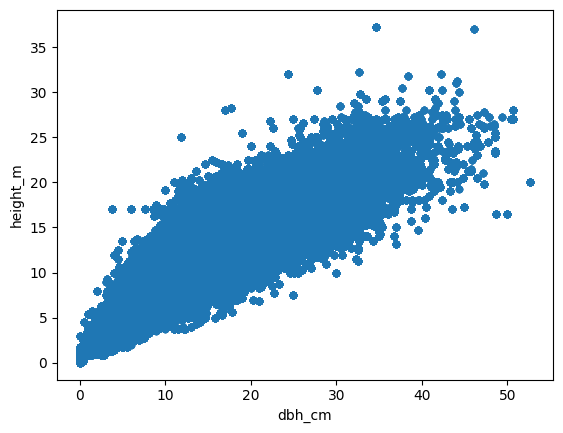

In [34]:
# Plot the relationship of height and diameter
df.plot(kind='scatter', x='dbh_cm', y='height_m')

<Axes: >

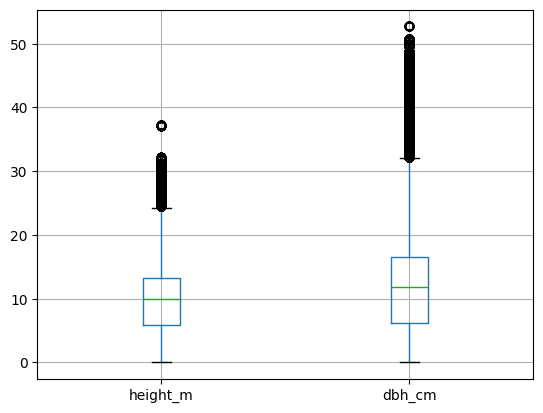

In [35]:
# Distribution of height and diameter data using boxplot
df[['height_m', 'dbh_cm']].boxplot()

<Axes: title={'center': 'DBH Distribution'}, ylabel='Frequency'>

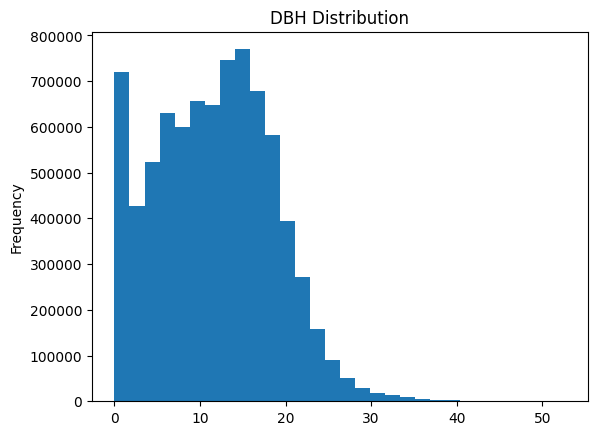

In [36]:
# Diameter distribution
df['dbh_cm'].plot.hist(bins=30, title="DBH Distribution")

<Axes: title={'center': 'Height Distribution'}, ylabel='Frequency'>

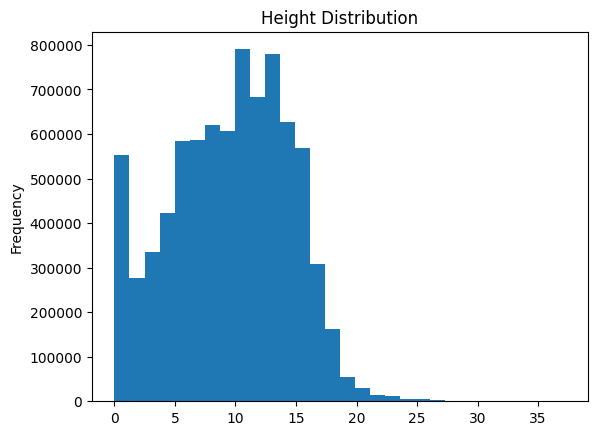

In [37]:
# Height Distribution
df['height_m'].plot.hist(bins=30, title="Height Distribution")